# 02 - Distribution Fitting Demo

This notebook demonstrates fitting the transformed nonstationary generalized distribution for one grid cell from the bundled ERA5/AORC fitting dataframe.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from stormlab.fitting import fit_tngd

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
OUTPUT_ROOT = REPO_ROOT / "output" / "examples_pipeline"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")

Repo root: c:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab
Data root exists: True


In [3]:
fitting_dir = DATA_ROOT / "era5" / "fitting_dataframe" / "1"

aorc_df = pd.read_csv(fitting_dir / "1_aorc.csv")
mtpr_df = pd.read_csv(fitting_dir / "1_mtpr.csv")
tcwv_df = pd.read_csv(fitting_dir / "1_tcwv.csv")

grid_index = aorc_df.columns[0]
training_df = pd.DataFrame(
    {
        "aorc": aorc_df[grid_index],
        "mean_total_precipitation_rate": mtpr_df[grid_index],
        "total_column_water_vapour": tcwv_df[grid_index],
    }
)

training_df.describe()

,aorc,mean_total_precipitation_rate,total_column_water_vapour
count,1533.000000,1533.000000,1533.000000
mean,0.385152,0.413257,5.038115
std,1.051673,1.012156,3.061034
min,0.000000,-0.000010,0.726616
25%,0.000000,0.010869,2.668242
50%,0.000000,0.062959,4.340673
75%,0.437500,0.323643,6.774303
max,16.562500,12.742559,20.733540


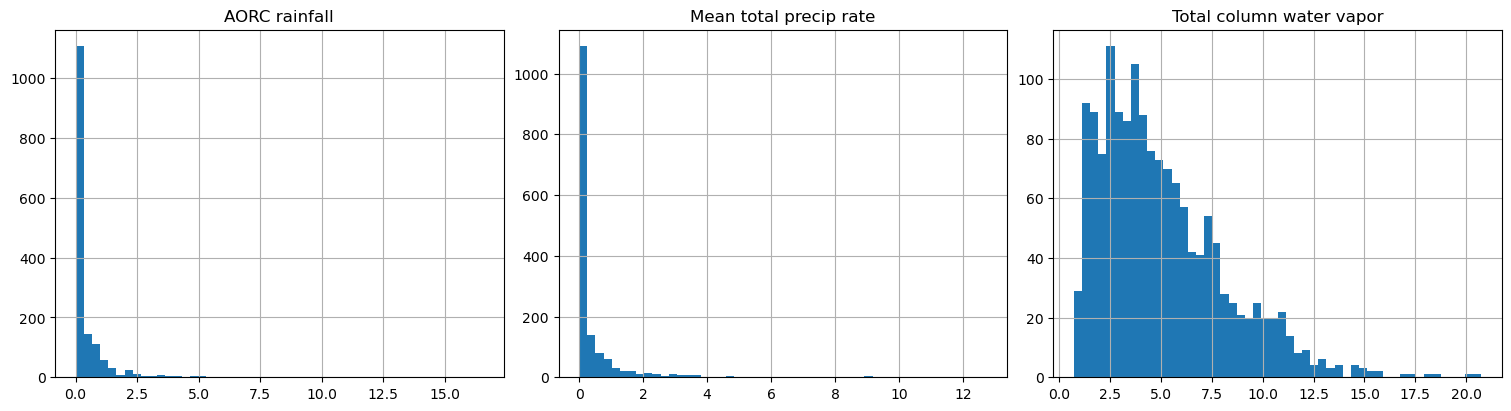

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
training_df["aorc"].hist(ax=axes[0], bins=50)
axes[0].set_title("AORC rainfall")
training_df["mean_total_precipitation_rate"].hist(ax=axes[1], bins=50)
axes[1].set_title("Mean total precip rate")
training_df["total_column_water_vapour"].hist(ax=axes[2], bins=50)
axes[2].set_title("Total column water vapor")
plt.show()

In [5]:
params = fit_tngd(
    data=training_df,
    y="aorc",
    x_list=["mean_total_precipitation_rate", "total_column_water_vapour"],
    mu_fix=False,
    sigma_fix=False,
)

params

,1,2,3,4,5,mu_clim,sigma_clim,loc_clim,gg_c
0,0.543361,0.619127,0.392533,0.412765,0.018677,0.910814,0.581571,0.0,0.485255


In [ ]:
# Optional save.
# params.to_csv(OUTPUT_ROOT / "tngd_params_one_grid.csv", index=False)